# Problem Statement

Suppose you work as a Data Analyst for a company that sells a consumer product across 200 different markets.

For each market, the company has recorded:

- How much money was spent on **TV advertising** (in thousands of dollars)
- How much money was spent on **Radio advertising**
- How much money was spent on **Newspaper advertising**
- The resulting **Sales** (in thousands of units)

The marketing team asks:

> "If we increase our TV advertising budget, how much more can we expect to sell?"

For simplicity, we will use only **one feature**.

**Feature (Input):**
- TV Advertising Budget (in $1000s)

**Target (Output):**
- Sales (in 1000s of units)

This is called **Simple Linear Regression**, because there is only **one input feature**.

**Dataset:** `Advertising.csv` — 200 rows, real market data (a classic dataset used in the ISLR statistics textbook).

**What we'll do in this notebook:**
1. Explore the data
2. Solve it **from scratch** using the closed-form OLS (mean) formula
3. Solve it **from scratch** using **Gradient Descent**, and see why feature scaling matters
4. Solve it using **scikit-learn**
5. Compare all three approaches

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Step 2: Load the Data

- Read `Advertising.csv` into a DataFrame called `df` (the first column is just a row index — set `index_col=0`)
- Look at `head()`, `shape`, and `describe()`

In [2]:
df = pd.read_csv('Advertising.csv', index_col=0)

print(df.shape)
display(df.describe())
df.head()

(200, 4)


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


# Step 3: Visualize the Relationship

- Plot a scatter plot of `TV` (x-axis) vs `Sales` (y-axis)

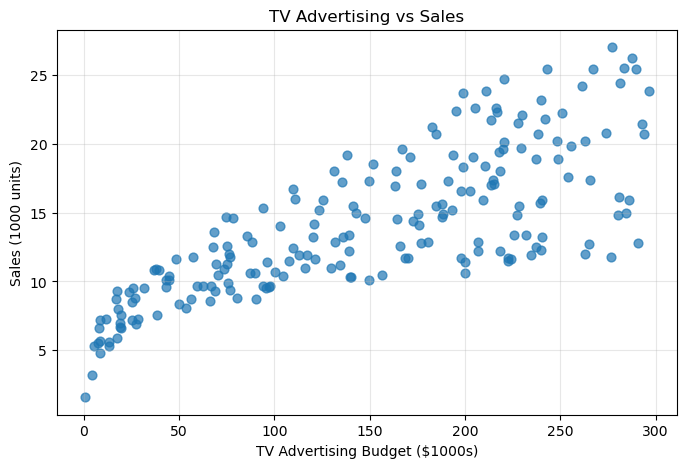

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(df['TV'], df['Sales'], s=40, alpha=0.7)
plt.xlabel('TV Advertising Budget ($1000s)')
plt.ylabel('Sales (1000 units)')
plt.title('TV Advertising vs Sales')
plt.grid(alpha=0.3)
plt.show()

# What is Linear Regression?

Linear Regression tries to find the **Best Fit Line** through the data.

Instead of remembering every data point, it learns a mathematical equation:

**Prediction = Slope × Input + Intercept**

Written mathematically:

**ŷ = m·x + b**

where
- ŷ = Predicted Sales
- m = Slope of the line
- x = TV Advertising Budget
- b = Intercept

We will find the best values of `m` and `b` in three different ways in this notebook.

# Part A: Solving From Scratch — Closed-Form OLS (Mean Formula)

The Ordinary Least Squares formula gives us the best-fit slope and intercept directly, without any iteration:

**m = Σ (x − x̄)(y − ȳ) / Σ (x − x̄)²**

**b = ȳ − m·x̄**

## Step A1: Extract x and y, and Compute Their Means

- Convert `df['TV']` and `df['Sales']` to lists (`x`, `y`)
- Compute `x_mean` and `y_mean`

In [4]:
x = df['TV'].tolist()
y = df['Sales'].tolist()
n = len(x)

x_mean = sum(x) / n
y_mean = sum(y) / n

print("Mean of X (TV) =", x_mean)
print("Mean of Y (Sales) =", y_mean)

Mean of X (TV) = 147.0425
Mean of Y (Sales) = 14.0225


## Step A2: Calculate the Numerator — Σ (x − x̄)(y − ȳ)

For every observation:
1. Find how far `x` is from its mean
2. Find how far `y` is from its mean
3. Multiply them
4. Add up all the products

In [5]:
numerator = 0

for i in range(n):
    x_diff = x[i] - x_mean
    y_diff = y[i] - y_mean
    numerator += x_diff * y_diff

print("Numerator =", numerator)

Numerator = 69727.64874999998


## Step A3: Calculate the Denominator — Σ (x − x̄)²

For every observation:
1. Find the distance from the mean
2. Square it
3. Add up all the squared values

In [6]:
denominator = 0

for i in range(n):
    x_diff = x[i] - x_mean
    denominator += x_diff ** 2

print("Denominator =", denominator)

Denominator = 1466819.0287500012


## Step A4: Compute Slope and Intercept

In [7]:
m_ols = numerator / denominator
b_ols = y_mean - (m_ols * x_mean)

print("Slope (m) =", m_ols)
print("Intercept (b) =", b_ols)

Slope (m) = 0.04753664043301969
Intercept (b) = 7.032593549127704


## Step A5: Generate Predictions and Plot the Regression Line

- Predict Sales for every value of `x` using `m_ols` and `b_ols`
- Overlay the regression line on the scatter plot

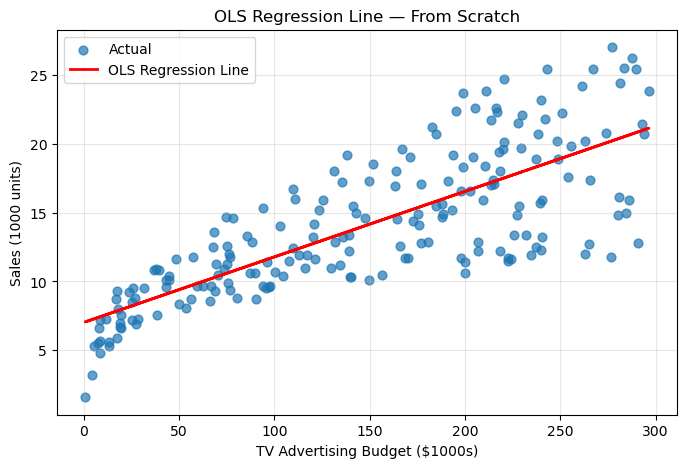

In [8]:
predictions_ols = [m_ols * xi + b_ols for xi in x]

plt.figure(figsize=(8,5))
plt.scatter(x, y, s=40, alpha=0.7, label='Actual')
plt.plot(x, predictions_ols, color='red', linewidth=2, label='OLS Regression Line')
plt.xlabel('TV Advertising Budget ($1000s)')
plt.ylabel('Sales (1000 units)')
plt.title('OLS Regression Line — From Scratch')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step A6: Calculate the Error (Mean Squared Error)

- For every observation, compute `error = actual - predicted`
- Compute the Mean Squared Error: `mse = mean(error^2)`
- Print the first 10 rows of Actual / Predicted / Error to inspect
- Print the final MSE

In [9]:
errors_ols = [y[i] - predictions_ols[i] for i in range(n)]
mse_ols = sum(e**2 for e in errors_ols) / n

print("TV\tActual\tPredicted\tError")
for i in range(10):
    print(f"{x[i]}\t{y[i]}\t{predictions_ols[i]:.2f}\t\t{errors_ols[i]:.2f}")

print("\nOLS (Closed-Form) Mean Squared Error =", mse_ols)

TV	Actual	Predicted	Error
230.1	22.1	17.97		4.13
44.5	10.4	9.15		1.25
17.2	9.3	7.85		1.45
151.5	18.5	14.23		4.27
180.8	12.9	15.63		-2.73
8.7	7.2	7.45		-0.25
57.5	11.8	9.77		2.03
120.2	13.2	12.75		0.45
8.6	4.8	7.44		-2.64
199.8	10.6	16.53		-5.93

OLS (Closed-Form) Mean Squared Error = 10.512652915656759


# Part B: Solving with Gradient Descent

The closed-form formula works great for small datasets, but for very large datasets (millions of rows, or many features) computing it directly becomes expensive. Instead, **Gradient Descent** finds `m` and `b` iteratively:

1. Start with a guess (usually `m = 0, b = 0`)
2. Make predictions, measure the error
3. Nudge `m` and `b` a little in the direction that reduces the error
4. Repeat for many iterations (epochs) until the error stops improving

## Step B1: A First (Naive) Attempt — Raw Scale

Let's try gradient descent directly on the raw `TV` values, the same way we would for a small toy dataset.

- Initialize `m = 0`, `b = 0`
- Set `learning_rate = 0.0001` and `epochs = 5`
- Run the gradient descent loop and print the MSE at every epoch
- **Watch what happens to the error**

In [10]:
import numpy as np

x_arr = np.array(x)
y_arr = np.array(y)

m_naive, b_naive = 0.0, 0.0
learning_rate = 0.0001
epochs = 5

for epoch in range(epochs):
    y_pred = m_naive * x_arr + b_naive
    error = y_pred - y_arr

    dm = (2/n) * np.sum(error * x_arr)
    db = (2/n) * np.sum(error)

    m_naive -= learning_rate * dm
    b_naive -= learning_rate * db

    mse = np.mean(error ** 2)
    print(f"Epoch {epoch}  m = {m_naive:.4f}  b = {b_naive:.4f}  MSE = {mse:.2f}")

Epoch 0  m = 0.4821  b = 0.0028  MSE = 223.72
Epoch 1  m = -1.8278  b = -0.0086  MSE = 4629.85
Epoch 2  m = 9.2396  b = 0.0480  MSE = 105778.27
Epoch 3  m = -43.7874  b = -0.2209  MSE = 2427766.24
Epoch 4  m = 210.2794  b = 1.0696  MSE = 55731894.47


### Observation

The error is **exploding**, not shrinking! This is because `TV` ranges from about 0.7 to 296 — a large, "un-scaled" range. With such large `x` values, the gradient (`dm`) becomes huge, so even a small learning rate causes `m` and `b` to overshoot wildly, and the model diverges instead of converging.

This is exactly why **feature scaling matters for Gradient Descent** — a small-scale feature keeps gradients small and stable, letting us use a sensible learning rate.

## Step B2: Standardize the Feature (Z-Score Scaling)

- Compute `x_mean` and `x_std` of the raw `TV` values
- Create a new array `x_scaled = (x - x_mean) / x_std`

In [11]:
x_mean_gd = x_arr.mean()
x_std_gd = x_arr.std()

x_scaled = (x_arr - x_mean_gd) / x_std_gd

print("Original TV range:", x_arr.min(), "to", x_arr.max())
print("Scaled TV range:", x_scaled.min().round(2), "to", x_scaled.max().round(2))

Original TV range: 0.7 to 296.4
Scaled TV range: -1.71 to 1.74


## Step B3: Run Gradient Descent on the Scaled Feature

- Initialize `m = 0`, `b = 0`
- Set `learning_rate = 0.01` and `epochs = 1000`
- Run the gradient descent loop on `x_scaled` and `y`
- Print the MSE every 100 epochs so we can watch it converge

In [12]:
m_gd, b_gd = 0.0, 0.0
learning_rate = 0.01
epochs = 1000

for epoch in range(epochs):
    y_pred = m_gd * x_scaled + b_gd
    error = y_pred - y_arr

    dm = (2/n) * np.sum(error * x_scaled)
    db = (2/n) * np.sum(error)

    m_gd -= learning_rate * dm
    b_gd -= learning_rate * db

    if epoch % 100 == 0:
        mse = np.mean(error ** 2)
        print(f"Epoch {epoch:4d}  m = {m_gd:.4f}  b = {b_gd:.4f}  MSE = {mse:.4f}")

print(f"\nFinal (scaled space) -> m = {m_gd:.6f}, b = {b_gd:.6f}")

Epoch    0  m = 0.0814  b = 0.2805  MSE = 223.7163
Epoch  100  m = 3.5419  b = 12.2000  MSE = 14.2625
Epoch  200  m = 4.0008  b = 13.7808  MSE = 10.5786
Epoch  300  m = 4.0617  b = 13.9904  MSE = 10.5138
Epoch  400  m = 4.0698  b = 14.0182  MSE = 10.5127
Epoch  500  m = 4.0708  b = 14.0219  MSE = 10.5127
Epoch  600  m = 4.0710  b = 14.0224  MSE = 10.5127
Epoch  700  m = 4.0710  b = 14.0225  MSE = 10.5127
Epoch  800  m = 4.0710  b = 14.0225  MSE = 10.5127
Epoch  900  m = 4.0710  b = 14.0225  MSE = 10.5127

Final (scaled space) -> m = 4.071006, b = 14.022500


## Step B4: Convert Coefficients Back to the Original Scale

Since we trained on `x_scaled = (x - x_mean) / x_std`, our learned line is:

**ŷ = m_gd · (x − x_mean)/x_std + b_gd**

Expanding this back in terms of the original `x`:

**ŷ = (m_gd / x_std) · x + (b_gd − m_gd · x_mean / x_std)**

- Compute `m_gd_original = m_gd / x_std_gd`
- Compute `b_gd_original = b_gd - m_gd * x_mean_gd / x_std_gd`
- Print both, and compare them to `m_ols` and `b_ols` from Part A

In [13]:
m_gd_original = m_gd / x_std_gd
b_gd_original = b_gd - (m_gd * x_mean_gd / x_std_gd)

print(f"Gradient Descent (original scale) -> Slope: {m_gd_original:.6f}, Intercept: {b_gd_original:.6f}")
print(f"Closed-form OLS   (original scale) -> Slope: {m_ols:.6f}, Intercept: {b_ols:.6f}")

Gradient Descent (original scale) -> Slope: 0.047537, Intercept: 7.032594
Closed-form OLS   (original scale) -> Slope: 0.047537, Intercept: 7.032594


## Step B5: Visualize the Gradient Descent Regression Line

- Plot the original scatter (`x`, `y`)
- Overlay the regression line using `m_gd_original` and `b_gd_original`

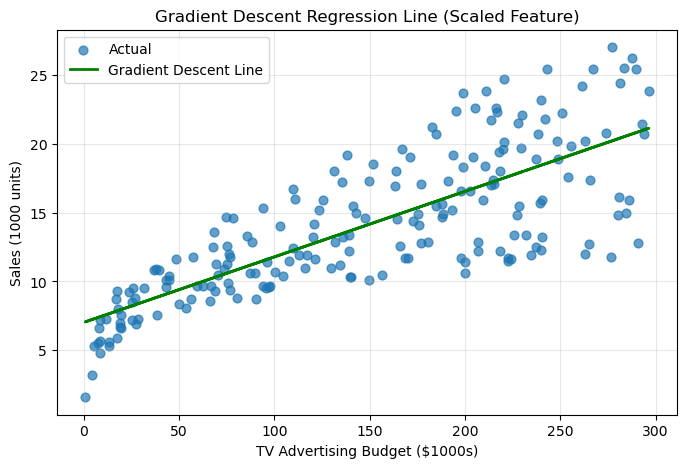

In [14]:
predictions_gd = [m_gd_original * xi + b_gd_original for xi in x]

plt.figure(figsize=(8,5))
plt.scatter(x, y, s=40, alpha=0.7, label='Actual')
plt.plot(x, predictions_gd, color='green', linewidth=2, label='Gradient Descent Line')
plt.xlabel('TV Advertising Budget ($1000s)')
plt.ylabel('Sales (1000 units)')
plt.title('Gradient Descent Regression Line (Scaled Feature)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step B6: Error Calculation for the Gradient Descent Model

- Compute the Mean Squared Error of `predictions_gd` against the actual `y`
- Compare it to `mse_ols` from Part A

In [15]:
mse_gd = sum((y[i] - predictions_gd[i])**2 for i in range(n)) / n

print("Gradient Descent MSE :", mse_gd)
print("Closed-Form OLS  MSE :", mse_ols)

Gradient Descent MSE : 10.51265291565676
Closed-Form OLS  MSE : 10.512652915656759


# Part C: Solving with scikit-learn

Now let's confirm our from-scratch results using the industry-standard library.

## Step C1: Train-Test Split

- `X = df[['TV']]` (2D), `y = df['Sales']`
- Split using `train_test_split()` with `test_size=0.2, random_state=42`

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['TV']]
y_full = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y_full, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(160, 1) (40, 1)


## Step C2: Fit the Model and Compare Coefficients

- Fit a `LinearRegression()` on `X_train, y_train`
- Print `lr.intercept_` and `lr.coef_[0]`
- Compare against `m_ols`/`b_ols` and `m_gd_original`/`b_gd_original`

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print(f"sklearn         -> Slope: {lr.coef_[0]:.6f}, Intercept: {lr.intercept_:.6f}")
print(f"Closed-form OLS -> Slope: {m_ols:.6f}, Intercept: {b_ols:.6f}")
print(f"Gradient Descent-> Slope: {m_gd_original:.6f}, Intercept: {b_gd_original:.6f}")

sklearn         -> Slope: 0.046530, Intercept: 7.119638
Closed-form OLS -> Slope: 0.047537, Intercept: 7.032594
Gradient Descent-> Slope: 0.047537, Intercept: 7.032594


## Step C3: Evaluate on the Test Set

- Predict on `X_test`
- Compute MSE and R² on the test set

In [18]:
y_pred_sklearn = lr.predict(X_test)

mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)

print(f"sklearn Test MSE : {mse_sklearn:.4f}")
print(f"sklearn Test R2  : {r2_sklearn:.4f}")

sklearn Test MSE : 10.2047
sklearn Test R2  : 0.6767


## Step C4: Predict Sales for a New TV Budget

- Use the fitted `lr` model to predict Sales if the company spends **$250,000 (250 in the dataset's units)** on TV advertising

In [19]:
new_budget = pd.DataFrame({'TV': [250]})
predicted_sales = lr.predict(new_budget)

print(f"Predicted Sales for a TV budget of $250,000: {predicted_sales[0]:.2f} (thousand units)")

Predicted Sales for a TV budget of $250,000: 18.75 (thousand units)


# Step D: Final Comparison

Build a small summary table comparing the slope, intercept, and MSE (on the full dataset, for a fair comparison) across all three methods:
- Closed-Form OLS
- Gradient Descent
- scikit-learn

In [20]:
y_pred_sklearn_full = lr.predict(X)
mse_sklearn_full = mean_squared_error(y_full, y_pred_sklearn_full)

summary = pd.DataFrame({
    'Method': ['Closed-Form OLS', 'Gradient Descent', 'scikit-learn'],
    'Slope (m)': [m_ols, m_gd_original, lr.coef_[0]],
    'Intercept (b)': [b_ols, b_gd_original, lr.intercept_],
    'MSE (full data)': [mse_ols, mse_gd, mse_sklearn_full]
})

summary

,Method,Slope (m),Intercept (b),MSE (full data)
0,Closed-Form OLS,0.047537,7.032594,10.512653
1,Gradient Descent,0.047537,7.032594,10.512653
2,scikit-learn,0.046530,7.119638,10.523811


# Summary

- All three approaches — closed-form OLS, gradient descent, and scikit-learn — converge to (almost) the **same slope and intercept**, confirming our from-scratch implementations are correct.
- Gradient Descent **diverged** on the raw `TV` scale, and only converged once we standardized the feature — a direct, practical illustration of why feature scaling matters for gradient-based optimization.
- The closed-form formula is exact and fast for small feature counts, but Gradient Descent is the approach that **scales** to large datasets and many features (where matrix inversion becomes computationally expensive).

**Happy Learning!**